# The t-test vs Wilcoxon on LLM Evaluation Scores

**O'Reilly Live Course**: *Statistical Testing for LLM Evaluations*  
**Subtitle**: *Design experiments that catch the improvements worth shipping*  
**Instructor**: Rudrendu Paul  
**Live Demo 2 of 2: Wilcoxon vs. t-test (6 min)**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RudrenduPaul/statistical-testing-for-llm-evaluations/blob/main/notebooks/02-hypothesis-testing-llm-metrics.ipynb)

---

## What this notebook covers

- Many LLM eval tools report a t-test or a mean difference (check yours). LLM quality scores rarely look normal: they cluster near the ceiling, carry a tail of failures, and are often ordinal (1-5 rubric).
- Live demo: the same 200 paired test cases go through a paired t-test and a Wilcoxon signed-rank test. The two reach different conclusions because they ask different questions.
- All data is simulated to show the mechanism. It is not scores from a production eval.

## How this notebook works

If you skim the code, this picture is the whole story. Each section answers one question, and the outputs below come from these steps.

<img src="https://raw.githubusercontent.com/RudrenduPaul/statistical-testing-for-llm-evaluations/aaa6e9c/assets/notebook-02-workflow.png" alt="Notebook 02 workflow in twelve steps across three sections: data, two tests, decision" width="1040">

**Figure 1.** The twelve steps of notebook 02, read left to right and top to bottom. The first four steps look at 200 paired scores and count the changes, the next four run the paired t-test and the Wilcoxon signed-rank test on those same scores, and the last four turn the two answers into a decision.

## Setup

Install the required libraries. Colab-safe: the cell below does nothing when the packages import cleanly, and installs them only when one is missing. Running locally, `scipy` is the one non-standard install.

In [1]:
import importlib, subprocess, sys
try:
    for _m in ('scipy', 'matplotlib', 'numpy'):
        importlib.import_module(_m)
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet',
                           'scipy', 'matplotlib', 'numpy'])

### Importing libraries

- NumPy: array math, reproducible random-number generation
- SciPy: the paired t-test and the Wilcoxon signed-rank test
- Matplotlib: plots

Note: Depending on the SciPy version, the Wilcoxon test can warn about ties or zero differences, which are common in ordinal rubric scores. Warnings are suppressed below to keep the demo clean, and Section 1 prints the tie count directly.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
# WHY suppress warnings: scipy.stats.wilcoxon can warn about ties or zero differences with
# ordinal rubric scores, depending on the SciPy version (many ties are expected
# for a 1-5 scale). Such a warning is not actionable in this notebook: we know ties are present.
# In production code, handle or log this warning rather than suppressing it globally.

# Reproducibility: every random draw in this notebook uses this seed.
# WHY fix the seed: students need to see the same numbers you describe in your
# commentary. A different seed can produce a run where the t-test and Wilcoxon
# agree, which would undercut the teaching point in Section 1.
np.random.seed(42)

# Global plot style: white background + light grid reads clearly on projectors
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'grid.linestyle': '--',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 110,
})

# Consistent color palette used for all charts in this notebook.
# WHY named constants: changing one variable updates every chart that uses it,
# which is essential when iterating on notebook design.
C_BLUE   = '#2166ac'   # model A / baseline
C_ORANGE = '#d6604d'   # model B / challenger
C_GREEN  = '#4dac26'   # better
C_GRAY   = '#aaaaaa'   # neutral / reference
C_RED    = '#d62728'   # worse

print('Libraries loaded. Seed set to 42.')

Libraries loaded. Seed set to 42.


---

## Section 1: Why the t-test can mislead on LLM metrics

### WHY THIS MATTERS

- Many LLM eval tools report a t-test or a mean difference for A/B comparisons (check yours), and teams ship on those p-values weekly.
- The t-test assumes normally distributed scores. LLM quality scores rarely are: they pile up near the ceiling ("good enough" outputs) with a long left tail of catastrophic failures. Running a t-test here is like measuring a curved surface with a straight ruler: precise-looking, wrong shape.

### What LLM quality score distributions look like

On a 1-5 rubric:

- **Ceiling effect**: scores cluster at 4 and 5, left-skewed not bell-shaped
- **Long left tail**: hallucinations, refusals, and format failures pull a few scores far down
- **Discrete values**: ordinal integers, not continuous measurements. The gap between 3 and 4 isn't guaranteed to equal the gap between 4 and 5

The cell below generates paired scores for a baseline prompt (A) and challenger (B) on the same 200 test cases. A t-test and a Wilcoxon test reach different conclusions on this dataset. All data in this notebook are simulated to illustrate the methods; they are not scores from a production eval.

**Teaching point**: a prompt change rarely improves every case uniformly. It typically helps the common case while breaking a few edge cases, which is what makes the mean a fragile summary.

In [3]:
np.random.seed(42)
N = 200  # test cases evaluated: 200 is a realistic mid-size eval set

# RATIONALE: These scores come from a PAIRED design: the same 200 test cases
# are scored under the baseline prompt (A) and the challenger prompt (B). The
# t-test / Wilcoxon comparison below runs on this same dataset.
#
# Step 1: a shared per-case "difficulty" factor. Easy cases score high under
# both prompts; hard cases score low under both. This shared factor is what
# makes the data paired.
difficulty = np.random.normal(0, 1.0, N)

# Step 2: baseline scores. Difficulty plus model noise, rounded and clipped to
# the 1-5 rubric. Rounding produces ties, which is normal for ordinal scores.
raw_a = difficulty + np.random.normal(3.6, 0.6, N)
scores_a = np.clip(np.round(raw_a).astype(int), 1, 5)

# Step 3: challenger scores. The challenger is a little better on
# MOST cases (a +1 bump on ~60% of items), unchanged on many others, but on a
# minority of cases it regresses badly: a prompt edit that helps the common
# case while breaking some hard inputs (format failures, refusals). Those large
# negative differences are realistic and they inflate the spread of the
# per-case difference, which is what trips up the t-test later.
u = np.random.random(N)
delta = np.zeros(N)
delta[u < 0.60] = 1.0                                   # ~60% improve by one point
big_regression = u >= 0.82                              # ~18% regress sharply
delta[big_regression] = -np.random.choice([3.0, 4.0], size=big_regression.sum())
raw_b = raw_a + delta
scores_b = np.clip(np.round(raw_b).astype(int), 1, 5)

# WHY this shape matters: B is better in the count of improved
# cases (rank-based tests will catch that), but the 30 regressions (mostly
# 2 to 4 points once scores are rounded and clipped) blow up the variance of the
# mean difference, so the mean barely moves relative to its noise. In that setup the t-test (did the average move?) and the Wilcoxon
# test (does B tend to win case by case?) give different answers, and we will see
# that play out below.
print('Baseline model (A) score distribution:')
for v in [1, 2, 3, 4, 5]:
    count = np.sum(scores_a == v)
    bar = '█' * count
    print(f'  Score {v}: {count:4d}  ({100*count/N:.1f}%)')

# WHAT THIS MEANS: the distribution is discrete and skewed toward the ceiling,
# with a left tail of 1s and 2s from the hard cases. Mean and median differ,
# a hallmark of skewed data and a warning that the mean is a fragile summary.
print(f'\nMean: {scores_a.mean():.3f}  |  Std: {scores_a.std():.3f}  |  Median: {np.median(scores_a):.1f}')
print(f'\nChallenger model (B): mean: {scores_b.mean():.3f}  |  median: {np.median(scores_b):.1f}')

Baseline model (A) score distribution:
  Score 1:    8  (4.0%)
  Score 2:   27  (13.5%)
  Score 3:   51  (25.5%)
  Score 4:   74  (37.0%)
  Score 5:   40  (20.0%)

Mean: 3.555  |  Std: 1.076  |  Median: 4.0

Challenger model (B): mean: 3.700  |  median: 4.0


### The scores and the per-case changes

- **Left**: both prompts pile up at 4 and 5, with a tail of 1s and 2s. Neither looks like a bell curve.
- **Right**: for each test case, B minus A. B gains one point on many cases (green) and loses two to four points on a smaller group (red). The two tests below react to that shape differently.

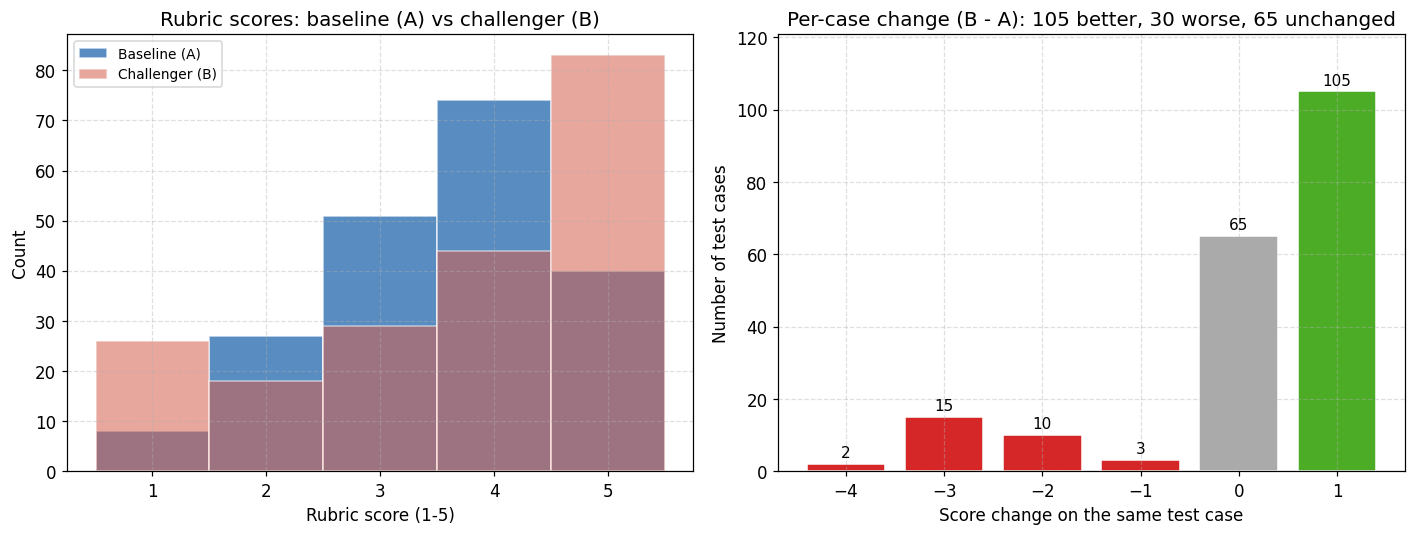

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: score distributions for baseline (A) and challenger (B)
ax = axes[0]
bins = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5]   # bins centered on the integer scores
ax.hist(scores_a, bins=bins, color=C_BLUE, alpha=0.75, edgecolor='white', label='Baseline (A)')
ax.hist(scores_b, bins=bins, color=C_ORANGE, alpha=0.55, edgecolor='white', label='Challenger (B)')
ax.set_title('Rubric scores: baseline (A) vs challenger (B)')
ax.set_xlabel('Rubric score (1-5)')
ax.set_ylabel('Count')
ax.set_xticks([1, 2, 3, 4, 5])
ax.legend(fontsize=9)

# Right: per-case change, B minus A
ax2 = axes[1]
diffs_plot = scores_b - scores_a
vals = np.arange(-4, 2)
counts = [int(np.sum(diffs_plot == v)) for v in vals]
bar_colors = [C_RED if v < 0 else (C_GRAY if v == 0 else C_GREEN) for v in vals]
ax2.bar(vals, counts, color=bar_colors, edgecolor='white')
for v, n in zip(vals, counts):
    ax2.text(v, n + 1, str(n), ha='center', va='bottom', fontsize=10)
ax2.set_title(f'Per-case change (B - A): {int(np.sum(diffs_plot > 0))} better, '
              f'{int(np.sum(diffs_plot < 0))} worse, {int(np.sum(diffs_plot == 0))} unchanged')
ax2.set_xlabel('Score change on the same test case')
ax2.set_ylabel('Number of test cases')
ax2.set_xticks(vals)
ax2.set_ylim(0, max(counts) * 1.15)

plt.tight_layout()
plt.show()

### What the t-test gets wrong on this data

The t-test relies on the mean and assumes normal residuals. On skewed or ordinal data the standard error is unreliable when a few large regressions inflate the variance, so the t-test and the rank-based tests can disagree.

The cell below runs a paired t-test and a Wilcoxon signed-rank test on the same scores. They answer different questions. The t-test asks whether the average moved. Wilcoxon asks whether B tends to beat A case by case.

**Why they differ here**: B wins 105 cases by one point and loses 30 cases, mostly by two to four points. The wins are numerous and small, the losses are fewer and large, so the mean moves little relative to its standard error while the ranks tilt toward B. Choose the test from the design (paired ordinal scores) before looking at p-values.

In [5]:
# RATIONALE: scores_a and scores_b are PAIRED (same 200 test cases under both
# prompts), so the correct comparison is a paired t-test vs the Wilcoxon
# signed-rank test. We run both here to preview the headline result of this
# notebook: on the same bounded, skewed data, the two tests disagree.

# Paired t-test (parametric: assumes the per-case DIFFERENCES are normal)
t_stat, p_ttest = stats.ttest_rel(scores_a, scores_b)

# Wilcoxon signed-rank (non-parametric: it ranks the per-case differences)
# WHY wilcoxon: it ranks the per-case differences instead of averaging them,
# so no single case can move the result as much as it moves the mean. It tests whether the differences are centered on zero.
w_stat, p_wilcoxon = stats.wilcoxon(scores_a, scores_b)

diffs_preview = scores_b - scores_a
n_up = int(np.sum(diffs_preview > 0))
n_dn = int(np.sum(diffs_preview < 0))

print('Comparing Baseline (A) vs Challenger (B), same N=200 test cases (paired)')
print(f'\n  Mean A: {scores_a.mean():.3f}   Mean B: {scores_b.mean():.3f}')
print(f'  Median A: {np.median(scores_a):.1f}   Median B: {np.median(scores_b):.1f}')
print(f'  Cases where B beat A: {n_up}   |   Cases where A beat B: {n_dn}')
# WHAT THE NUMBERS TELL US: B wins on far more cases than it loses, and the
# median is the same, but the mean barely moves relative to its noise, because
# the larger regressions drag the average down and inflate its standard error.
loss_sizes = -diffs_preview[diffs_preview < 0]
win_sizes = diffs_preview[diffs_preview > 0]
n_big_loss = int(np.sum(loss_sizes >= 2))
n_ties = int(np.sum(diffs_preview == 0))
print(f'  Win sizes (points): {sorted(set(int(v) for v in win_sizes))}')
print(f'  Loss sizes (points -> count): {dict(zip(*[[int(v) for v in arr] for arr in np.unique(loss_sizes, return_counts=True)]))}')
print(f'  {n_big_loss} of the {n_dn} losses are 2 to 4 points')
print(f'  {n_ties} ties are set aside by Wilcoxon, so {n_up + n_dn} cases decide the result')
print()
print(f'  Paired t-test  : t={t_stat:.3f},  p={p_ttest:.4f}  ← compares the mean difference')
print(f'  Wilcoxon s-r   : W={w_stat:.0f},  p={p_wilcoxon:.4f}  ← ranks the per-case differences')
print()

# THE FLIP: the t-test and Wilcoxon reach OPPOSITE conclusions on this data.
sig_t = p_ttest < 0.05
sig_w = p_wilcoxon < 0.05
if sig_t != sig_w:
    print('  The tests DISAGREE.')
    print(f'    t-test  p={p_ttest:.4f} → {"significant" if sig_t else "NOT significant"}')
    print(f'    Wilcoxon p={p_wilcoxon:.4f} → {"significant" if sig_w else "NOT significant"}')
    print('  The tests answer different questions. The t-test asks whether the average moved.')
    print('  Wilcoxon asks whether B tends to beat A case by case.')
else:
    print('  The tests agree on this sample.')

print()
print(f'  Key point: B wins {n_up} cases by one point and loses {n_dn} cases, {n_big_loss} of them by two to four points.')
print('  Whether to ship depends on what those regressions cost. Choose the test from the')
print('  design (paired ordinal scores) before looking at p-values.')

Comparing Baseline (A) vs Challenger (B), same N=200 test cases (paired)

  Mean A: 3.555   Mean B: 3.700
  Median A: 4.0   Median B: 4.0
  Cases where B beat A: 105   |   Cases where A beat B: 30
  Win sizes (points): [1]
  Loss sizes (points -> count): {1: 3, 2: 10, 3: 15, 4: 2}
  27 of the 30 losses are 2 to 4 points
  65 ties are set aside by Wilcoxon, so 135 cases decide the result

  Paired t-test  : t=-1.641,  p=0.1024  ← compares the mean difference
  Wilcoxon s-r   : W=3458,  p=0.0078  ← ranks the per-case differences

  The tests DISAGREE.
    t-test  p=0.1024 → NOT significant
    Wilcoxon p=0.0078 → significant
  The tests answer different questions. The t-test asks whether the average moved.
  Wilcoxon asks whether B tends to beat A case by case.

  Key point: B wins 105 cases by one point and loses 30 cases, 27 of them by two to four points.
  Whether to ship depends on what those regressions cost. Choose the test from the
  design (paired ordinal scores) before looking a

### KEY INSIGHT

- Paired t-test (did the average move?): p=0.1024, not significant. Wilcoxon signed-rank (does B tend to win case by case?): p=0.0078, significant. Same scores.
- B wins 105 cases by one point and loses 30 cases, 27 of them by two to four points. 65 ties are set aside, so 135 cases decide the Wilcoxon result.
- The few large losses pull the average down and widen its standard error, so the t-test sees little movement. Ranking caps how much each loss counts, so Wilcoxon sees B winning far more often than losing.

**For production**: if your eval tool reports a t-test p-value on rubric-scored outputs, check which question it answers. For paired ordinal scores, Wilcoxon matches the design, and it is a one-line call in scipy. Then look at the size of the regressions before deciding to ship.

---

*This notebook accompanies the O'Reilly Live Course: **Statistical Testing for LLM Evaluations**, by Rudrendu Paul. All data is simulated.*